In [1]:
#%%
%load_ext autoreload
%autoreload 2

In [41]:
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
from copy import deepcopy, copy
import random
import torch
#load the dataset
from folktexts.acs.acs_dataset import ACSDataset
from monoculture.baseline import BaselineClassifier
from folktexts.benchmark import Benchmark as ft_benchmark

# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier

# from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier

SEED = 42
data_dir = Path.cwd() / "data"

## Tableshift

In [5]:
from folktexts.ts.brfss_dataset import TableshiftBRFSSDataset

In [43]:
task_name = 'BRFSS_Blood_Pressure'
dataset = TableshiftBRFSSDataset.make_from_task(task=task_name, cache_dir=data_dir, **ft_benchmark.TABLESHIFT_DATASET_CONFIGS)

In [53]:
X_train, y_train = dataset.get_train()
X_test, y_test = dataset.get_test()
s_test = None
if dataset.task.sensitive_attribute is not None:
    s_test = dataset.get_sensitive_attribute_data().loc[y_test.index]

In [55]:
for X in [X_train, X_test]:
    X.fillna(value=-1., inplace=True)
    for col in X_train.select_dtypes(exclude=[np.number]).columns:
        X.replace(to_replace='NOTASKED_MISSING', value=-2., inplace=True)
        X[col] = pd.to_numeric(X[col])
X_test#.dtypes

SMOKDAY2


,BMI5CAT,AGEG5YR,FRUIT_ONCE_PER_DAY,VEG_ONCE_PER_DAY,DRNK_PER_WEEK,RFBING5,TOTINDA,SMOKE100,SMOKDAY2,CHCSCNCR,CHCOCNCR,DIABETES,POVERTY,EMPLOY1,IYEAR,STATE,MEDCOST,PRACE1,SEX
686618,3.0,7.0,1.0,2.0,100.0,1.0,1.0,2.0,NOTASKED_MISSING,1.0,2.0,3.0,0,1.0,2021.0,17.0,2.0,1,0
723936,4.0,8.0,1.0,1.0,0.0,1.0,2.0,1.0,1.0,2.0,2.0,4.0,1,8.0,2021.0,26.0,2.0,1,1
270533,3.0,9.0,2.0,1.0,2400.0,2.0,1.0,2.0,NOTASKED_MISSING,2.0,2.0,1.0,0,1.0,2017.0,15.0,2.0,0,0
469143,4.0,7.0,2.0,1.0,0.0,1.0,1.0,2.0,NOTASKED_MISSING,2.0,2.0,1.0,0,1.0,2019.0,9.0,2.0,1,0
688134,3.0,11.0,2.0,1.0,1200.0,1.0,1.0,1.0,3.0,2.0,2.0,3.0,0,7.0,2021.0,18.0,2.0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99268,4.0,10.0,1.0,1.0,200.0,1.0,1.0,1.0,1.0,2.0,2.0,3.0,1,7.0,2015.0,27.0,2.0,1,0
174526,2.0,7.0,1.0,1.0,0.0,1.0,1.0,1.0,2.0,2.0,2.0,1.0,1,8.0,2015.0,45.0,1.0,1,0
98005,3.0,9.0,1.0,1.0,467.0,1.0,2.0,1.0,1.0,1.0,2.0,3.0,0,1.0,2015.0,27.0,2.0,1,1
723344,4.0,9.0,2.0,1.0,1750.0,2.0,1.0,1.0,3.0,2.0,1.0,1.0,0,4.0,2021.0,25.0,2.0,1,0


In [42]:
xgboost_clf = DummyClassifier(random_state = SEED)
xgboost_clf.fit(X_train, y_train)
(xgboost_clf.predict(X_test) == y_test).mean()

0.8676134553864476

## ACS Income

In [4]:
task_name = "ACSIncome"
acs_dataset_configs = ft_benchmark.ACS_DATASET_CONFIGS
acs_dataset_configs

{'survey_year': '2018',
 'horizon': '1-Year',
 'survey': 'person',
 'test_size': 0.1,
 'val_size': 0.1,
 'subsampling': None,
 'seed': 42}

In [39]:
dataset = ACSDataset.make_from_task(
    task_name, cache_dir=data_dir, **acs_dataset_configs
)

X_train, y_train = dataset.get_train()
X_test, y_test = dataset.get_test()
s_test = None
if dataset.task.sensitive_attribute is not None:
    s_test = dataset.get_sensitive_attribute_data().loc[y_test.index]

In [6]:
from folktables import ACSDataSource, ACSIncome
from sklearn.model_selection import train_test_split

data_source = ACSDataSource(survey_year='2018', horizon='1-Year', survey='person',root_dir=data_dir/'folktables')
acs_data = data_source.get_data()

features, label, group = ACSIncome.df_to_pandas(acs_data)
X_train_2, X_test_2, y_train_2, y_test_2, group_train, group_test = train_test_split(features, label, group, test_size=0.2, random_state=SEED)

Test: Does it make a difference whether data is scaled?

In [7]:
xgboost_clf = XGBClassifier(random_state = SEED)
xgboost_clf.fit(X_train, y_train)
(xgboost_clf.predict(X_test) == y_test).mean()

0.8173085010513668

In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # scales data to 0-mean, 1-std
scaler.fit(X_train, y_train) # scaling based on training data

xgboost_clf_scaled = XGBClassifier()
xgboost_clf_scaled.fit(scaler.transform(X_train), y_train)
(xgboost_clf_scaled.predict(scaler.transform(X_test)) == y_test).mean()

0.8173085010513668

In [9]:
X_train.mean(axis=0)

AGEP       43.410895
COW         2.077950
SCHL       18.618307
MAR         2.520735
OCCP     4181.682243
POBP       65.840957
RELP        2.240444
WKHP       38.331817
SEX         1.479261
RAC1P       1.874715
dtype: float64

In [10]:
scaler.transform(X_train).mean(axis=0)

array([-2.12554516e-16,  4.09858723e-17, -3.80281234e-16, -1.01026627e-16,
        6.74791487e-17,  1.92603184e-17,  6.10439238e-18,  9.95698967e-18,
        3.10128746e-17,  3.39049906e-17])

In [11]:
base_clf = BaselineClassifier(model_name = 'LogisticRegression', task='ACSIncome', clf_params={'strategy': 'prior', 'penalty': 'l2'})
base_clf

BaselineClassifier(clf_params={'penalty': 'l2', 'random_state': 42},
                   model_name='LogisticRegression',
                   task=ACSTaskMetadata(name='ACSIncome',
                                        features=['AGEP', 'COW', 'SCHL', 'MAR',
                                                  'OCCP', 'POBP', 'RELP',
                                                  'WKHP', 'SEX', 'RAC1P'],
                                        target='PINCP',
                                        cols_to_text={'AGEP': <folktexts.col_to_text.ColumnToText object at 0x3041056d0>,
                                                      'ANC': <folktexts.col_to_text.ColumnToText obj...
                                        direct_numeric_qa=DirectNumericQA(column='PINCP>50000',
                                                                          text='What '
                                                                               'is '
                                                                               'the '
                                                                               'probability '
                                                                               'that '
                                                                               'this '
                                                                               "person's "
                                                                               'estimated '
                                                                               'yearly '
                                                                               'income '
                                                                               'is '
                                                                               'above '
                                                                               '$50,000 '
                                                                               '?',
                                                                          num_forward_passes=2,
                                                                          answer_probability=True),
                                        description='predict whether an '
                                                    "individual's income is "
                                                    'above $50,000',
                                        _use_numeric_qa=False,
                                        folktables_obj=<folktables.folktables.BasicProblem object at 0x303e1f290>))

### Train on different subsets of the data

In [12]:
# create 10 subsets
rng = np.random.default_rng()
train_indices = rng.permutation(X_train.index.to_numpy())

num_subsets = 22
subset_size = int( len(train_indices) // num_subsets) #0.05 *
print('Size of subsets: ', subset_size)

subsets = [
    (
        X_train.loc[train_indices[subset_size * i : subset_size * (i + 1)]],
        y_train.loc[train_indices][subset_size * i : subset_size * (i + 1)],
    )
    for i in range(num_subsets)
]

Size of subsets:  60527


In [13]:
num_pos = len(y_test[y_test==1])

#### Logistic Regression

a logistic regression problem (without perfect separation) has a global optimum, and so there are no local optima to get stuck in with different random seeds. If the solver converges satisfactorily, it will do so on the global optimum. So the only time random_state can have any effect is when the solver fails to converge

In [14]:
logreg_clf = BaselineClassifier(model_name = 'LogisticRegression', task='ACSIncome', clf_params={'penalty': 'l2', 'max_iter': 500})
logreg_clf.fit(X_train, y_train)
print(f'accuracy: {(logreg_clf.predict(X_test) == y_test).mean()}')

accuracy: 0.7545328927605888


/Users/mgorecki/opt/miniconda3/envs/monoc-py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
logreg_clf_subset = []
for X_subset, y_subset in subsets:
    base_clf = BaselineClassifier(model_name = 'LogisticRegression', task='ACSIncome', clf_params={'penalty': 'l2', 'max_iter': 500})
    base_clf.fit(X_subset, y_subset)
    logreg_clf_subset.append(base_clf)



/Users/mgorecki/opt/miniconda3/envs/monoc-py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/mgorecki/opt/miniconda3/envs/monoc-py311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-lear

In [16]:
logreg_predictions_subset = pd.DataFrame.from_dict({i: pd.Series(clf.predict(X_test), index=X_test.index) for i, clf in enumerate(logreg_clf_subset)})
logreg_predictions_subset

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
238351,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2995677,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2360043,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1924596,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2803585,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43637,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2494279,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2989522,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
688458,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


In [17]:
fnrs = logreg_predictions_subset.apply(lambda col: col != y_test, axis=0)[y_test==1].mean(axis=0)
accuracies = logreg_predictions_subset.apply(lambda col: col == y_test, axis=0).mean(axis=0)
accuracies.values

array([0.75482728, 0.75402824, 0.75499549, 0.75537399, 0.75335536,
       0.75493542, 0.75414839, 0.75482728, 0.75580054, 0.75455092,
       0.75450285, 0.75401021, 0.7544608 , 0.75352358, 0.75416642,
       0.75462301, 0.75518774, 0.75478522, 0.75479123, 0.75449084,
       0.75424452, 0.75438871])

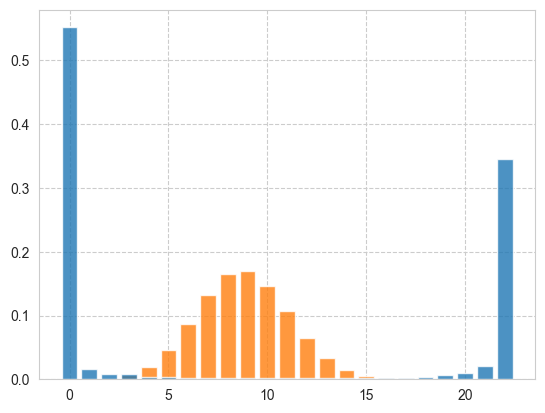

In [18]:
prob_expected = np.array([sp.stats.poisson_binom.pmf(k=num_rejections, p=fnrs.values) for num_rejections in range(len(subsets) + 1)])
vals, counts = np.unique((len(subsets) - logreg_predictions_subset[y_test==1].sum(axis=1).to_numpy()), return_counts=True)

plt.bar(np.arange(len(subsets)+1), prob_expected, color="C1", alpha=0.8, align='center')
plt.bar(vals, counts/num_pos, color="C0", alpha=0.8, align='center')
plt.show()

#### XGBoost

In [19]:
xgboost_clf = BaselineClassifier(model_name = 'XGBoost', task='ACSIncome', clf_params={})
xgboost_clf.fit(X_train, y_train)
print(f'accuracy: {(xgboost_clf.predict(X_test) == y_test).mean()}')

accuracy: 0.8173085010513668


In [20]:
xgboost_clf_subset = []
xgboost_predictions_subset = []
for i, (X_subset, y_subset) in enumerate(subsets):
    base_clf = BaselineClassifier(model_name = 'XGBoost', task='ACSIncome', clf_params={})
    base_clf.fit(X_subset, y_subset)
    xgboost_clf_subset.append(base_clf)
    xgboost_predictions_subset.append(pd.Series(base_clf.predict(X_test), index=X_test.index) )

In [21]:
xgboost_predictions_subset[0]

238351     0
2995677    0
2360043    1
1924596    0
2803585    0
          ..
43637      0
2494279    0
2989522    0
688458     1
1778641    0
Length: 166450, dtype: int64

In [22]:
#xgboost_predictions_subset = pd.DataFrame.from_dict({i: pd.Series(clf.predict(X_test), index=X_test.index) for i, clf in enumerate(xgboost_clf_subset)})
xgboost_predictions_subset = pd.DataFrame(pd.concat(xgboost_predictions_subset, axis=1))
# xgboost_predictions_subset

In [23]:
fnrs = xgboost_predictions_subset.apply(lambda col: col != y_test, axis=0)[y_test==1].mean(axis=0) # only positive instances
accuracies = xgboost_predictions_subset.apply(lambda col: col == y_test, axis=0).mean(axis=0)
accuracies

0     0.809913
1     0.810982
2     0.808958
3     0.810520
4     0.810261
5     0.810177
6     0.809769
7     0.809372
8     0.810285
9     0.810544
10    0.810484
11    0.810327
12    0.809913
13    0.810592
14    0.808892
15    0.810243
16    0.810141
17    0.809342
18    0.809859
19    0.810640
20    0.809937
21    0.809276
dtype: float64

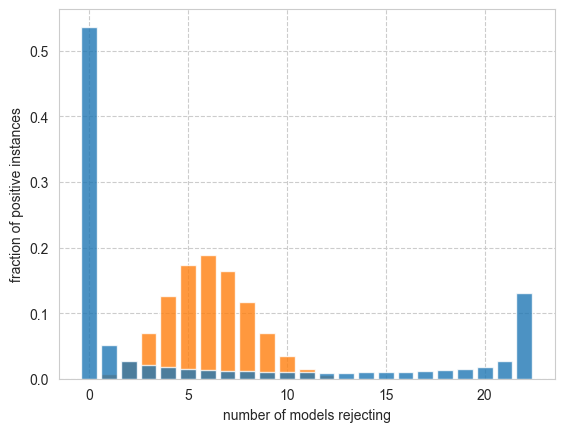

In [24]:
prob_expected = np.array([sp.stats.poisson_binom.pmf(k=num_rejections, p=fnrs.values) for num_rejections in range(len(subsets) + 1)])
vals, counts = np.unique((len(subsets) - xgboost_predictions_subset[y_test==1].sum(axis=1).to_numpy()), return_counts=True)

plt.bar(np.arange(len(subsets)+1), prob_expected, color="C1", alpha=0.8, align='center')
plt.bar(vals, counts/num_pos, color="C0", alpha=0.8, align='center')
plt.xlabel('number of models rejecting')
plt.ylabel('fraction of positive instances')
plt.show()

### Train on same data, different random seeds

In [25]:
X_train_small, y_train_small = subsets[0]
X_train_small.shape

(60527, 10)

In [49]:
np.random.seed(seed=244) #89589)
rand_states = np.random.randint(0, high=10000, size=(num_subsets,))
rand_states

array([6634, 3016, 8573, 2523, 9626, 4234, 7077, 8387, 6952, 6499, 5497,
       3978, 3226, 2770, 6488,  762, 8763, 5041, 6820,  348, 9697, 6530])

In [50]:
from xgboost import XGBClassifier
from xgboost import XGBModel
from sklearn.linear_model import LogisticRegression


In [51]:
xgboost_clf_seeded = []
xgboost_predictions_seeded = np.empty((len(X_test), len(rand_states)))

for seed in rand_states:

    print(seed, end=', ')
    seed = int(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    base_clf = BaselineClassifier(model_name = 'XGBoost', task='ACSIncome', seed=seed)
    base_clf.fit(X_train_small, y_train_small) #train on one fixed subset
    xgboost_clf_seeded.append(base_clf)
    xgboost_predictions_seeded[:,i] = deepcopy(base_clf.predict(X_test))
    
xgboost_predictions_seeded = pd.DataFrame(xgboost_predictions_seeded, index=X_test.index).astype(int)

6634, 3016, 8573, 2523, 9626, 4234, 7077, 8387, 6952, 6499, 5497, 3978, 3226, 2770, 6488, 762, 8763, 5041, 6820, 348, 9697, 6530, 

In [52]:
xgboost_clf_seeded[0]

BaselineClassifier(clf_params={'random_state': 6634}, model_name='XGBoost',
                   seed=6634,
                   task=ACSTaskMetadata(name='ACSIncome',
                                        features=['AGEP', 'COW', 'SCHL', 'MAR',
                                                  'OCCP', 'POBP', 'RELP',
                                                  'WKHP', 'SEX', 'RAC1P'],
                                        target='PINCP',
                                        cols_to_text={'AGEP': <folktexts.col_to_text.ColumnToText object at 0x3041056d0>,
                                                      'ANC': <folktexts.col_to_text.ColumnToText object at 0x3041113...
                                        direct_numeric_qa=DirectNumericQA(column='PINCP>50000',
                                                                          text='What '
                                                                               'is '
                                                                               'the '
                                                                               'probability '
                                                                               'that '
                                                                               'this '
                                                                               "person's "
                                                                               'estimated '
                                                                               'yearly '
                                                                               'income '
                                                                               'is '
                                                                               'above '
                                                                               '$50,000 '
                                                                               '?',
                                                                          num_forward_passes=2,
                                                                          answer_probability=True),
                                        description='predict whether an '
                                                    "individual's income is "
                                                    'above $50,000',
                                        _use_numeric_qa=False,
                                        folktables_obj=<folktables.folktables.BasicProblem object at 0x303e1f290>))

In [53]:
xgboost_predictions_seeded

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
238351,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2995677,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2360043,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1924596,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2803585,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43637,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2494279,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2989522,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
688458,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [59]:
# directly use XGBClassifier, not wrapped version
xgboost_predictions_seeded = np.empty((len(X_test), len(rand_states)))
for i, seed in enumerate(rand_states):
    clf = XGBClassifier(random_state=seed)
    clf.fit(X_train_small, y_train_small)
    xgboost_predictions_seeded[:,i] = deepcopy(clf.predict(X_test))
xgboost_predictions_seeded = pd.DataFrame(xgboost_predictions_seeded, index=X_test.index)

In [60]:
xgboost_predictions_seeded.apply(lambda col: col != y_test, axis=0)[y_test==1]

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
2360043,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2803585,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1903695,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
620866,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1692440,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995426,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
3187549,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1588752,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
926337,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [63]:
fnrs = xgboost_predictions_seeded.apply(lambda col: col != y_test, axis=0)[y_test==1].mean(axis=0) # only positive instances
accuracies = xgboost_predictions_seeded.apply(lambda col: col == y_test, axis=0).mean(axis=0)
fnrs.values

array([0.27584799, 0.27584799, 0.27584799, 0.27584799, 0.27584799,
       0.27584799, 0.27584799, 0.27584799, 0.27584799, 0.27584799,
       0.27584799, 0.27584799, 0.27584799, 0.27584799, 0.27584799,
       0.27584799, 0.27584799, 0.27584799, 0.27584799, 0.27584799,
       0.27584799, 0.27584799])

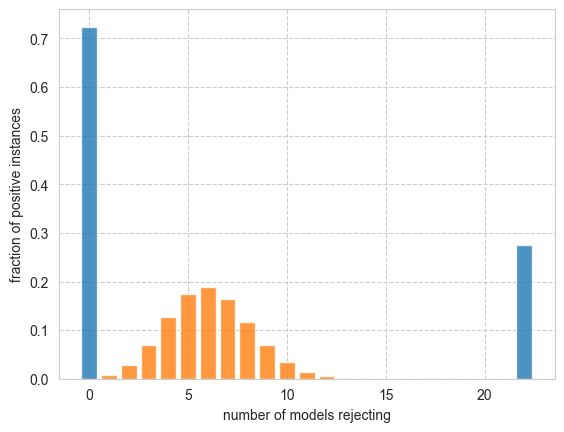

In [62]:
num_clfs = xgboost_predictions_seeded.shape[1]
prob_expected = np.array([sp.stats.poisson_binom.pmf(k=num_rejections, p=fnrs.values) for num_rejections in range(num_clfs + 1)])
vals, counts = np.unique((num_clfs - xgboost_predictions_seeded[y_test==1].sum(axis=1).to_numpy()), return_counts=True)

plt.bar(np.arange(num_clfs+1), prob_expected, color="C1", alpha=0.8, align='center')
plt.bar(vals, counts/num_pos, color="C0", alpha=0.8, align='center')
plt.xlabel('number of models rejecting')
plt.ylabel('fraction of positive instances')
plt.show()

In [ ]:
# # read data
# from sklearn.datasets import load_iris
# from sklearn.model_selection import train_test_split
# data = load_iris()
# X_train, X_test, y_train, y_test = train_test_split(data['data'], data['target'], test_size=.2, random_state=30)# 3 , shuffle=False)
# # create model instance
# bst = XGBClassifier(n_estimators=20, max_depth=5, learning_rate=1, objective='binary:logistic', seed=302)  #, random_state=rand_states[0])
# # fit model
# bst.fit(X_train, y_train)
# # make predictions
# preds = bst.predict(X_test)
# (preds == y_test).mean()

0.9333333333333333